In [1]:
if (!require("randomForest")) install.packages("randomForest", repos = "https://cran.rstudio.com/")
library(randomForest)

Loading required package: randomForest


randomForest 4.6-14
Type rfNews() to see new features/changes/bug fixes.


In [2]:
data(iris)
set.seed(42)

In [3]:
train_idx <- sample(1:nrow(iris), 0.7 * nrow(iris))
train_data <- iris[train_idx, ]
test_data  <- iris[-train_idx, ]

In [4]:
rf_model <- randomForest(Species ~ ., data = train_data, ntree = 500, importance = TRUE)


Call:
 randomForest(formula = Species ~ ., data = train_data, ntree = 500,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 5.71%
Confusion matrix:
           setosa versicolor virginica class.error
setosa         38          0         0  0.00000000
versicolor      0         33         2  0.05714286
virginica       0          4        28  0.12500000


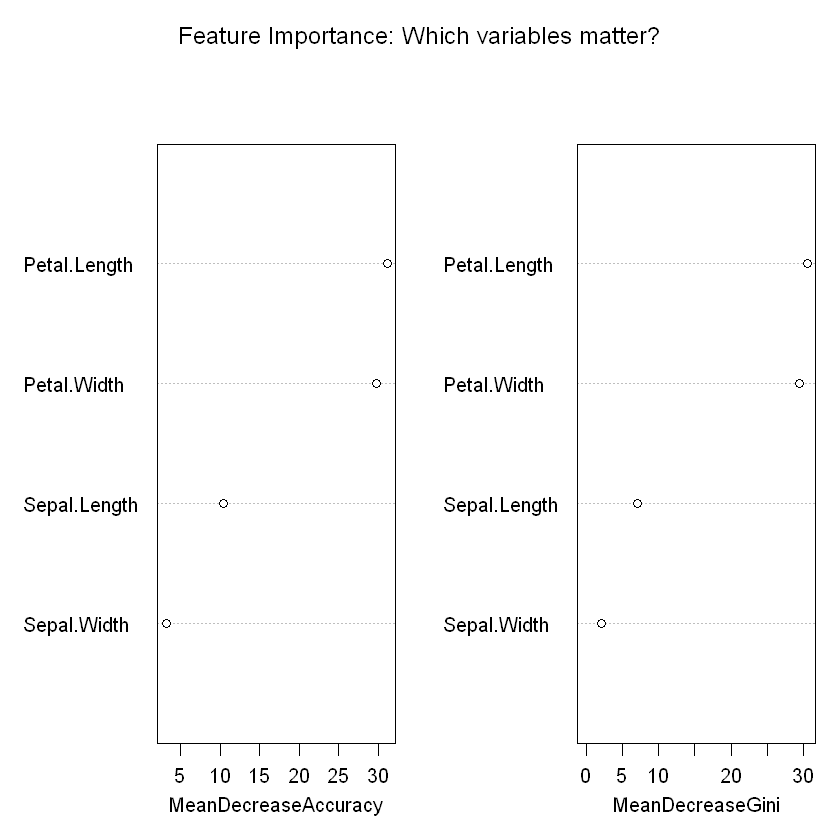

In [5]:
print(rf_model)
varImpPlot(rf_model, main = "Feature Importance: Which variables matter?")

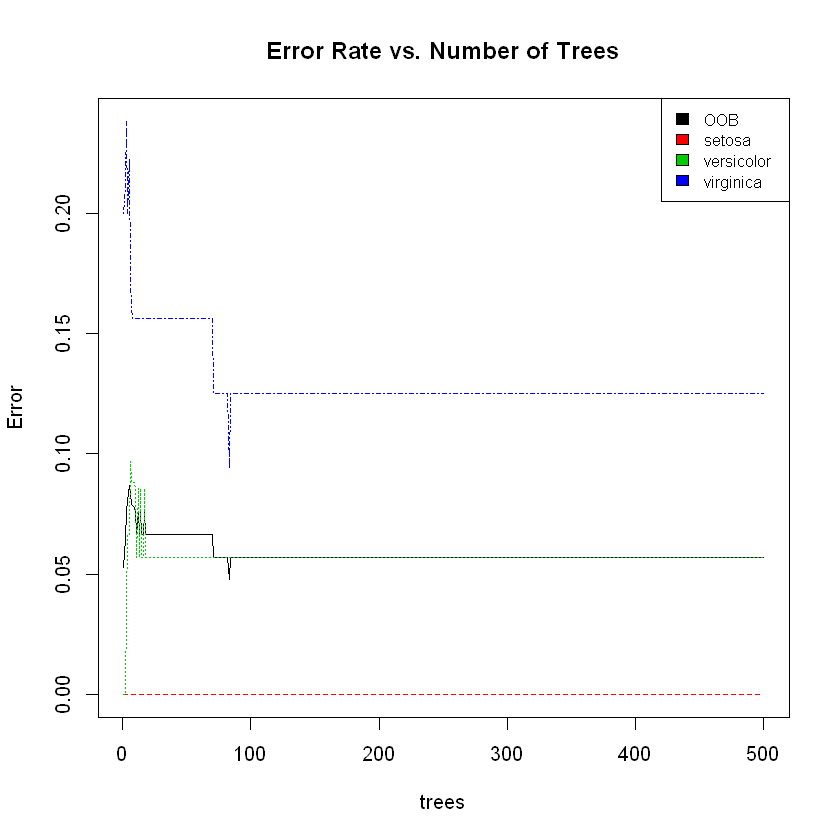

In [6]:
plot(rf_model, main = "Error Rate vs. Number of Trees")
legend("topright", colnames(rf_model$err.rate), col=1:4, cex=0.8, fill=1:4)

mtry = 2  OOB error = 5.71% 
Searching left ...
Searching right ...
mtry = 3 	OOB error = 4.76% 
0.1666667 0.01 
mtry = 4 	OOB error = 6.67% 
-0.4 0.01 


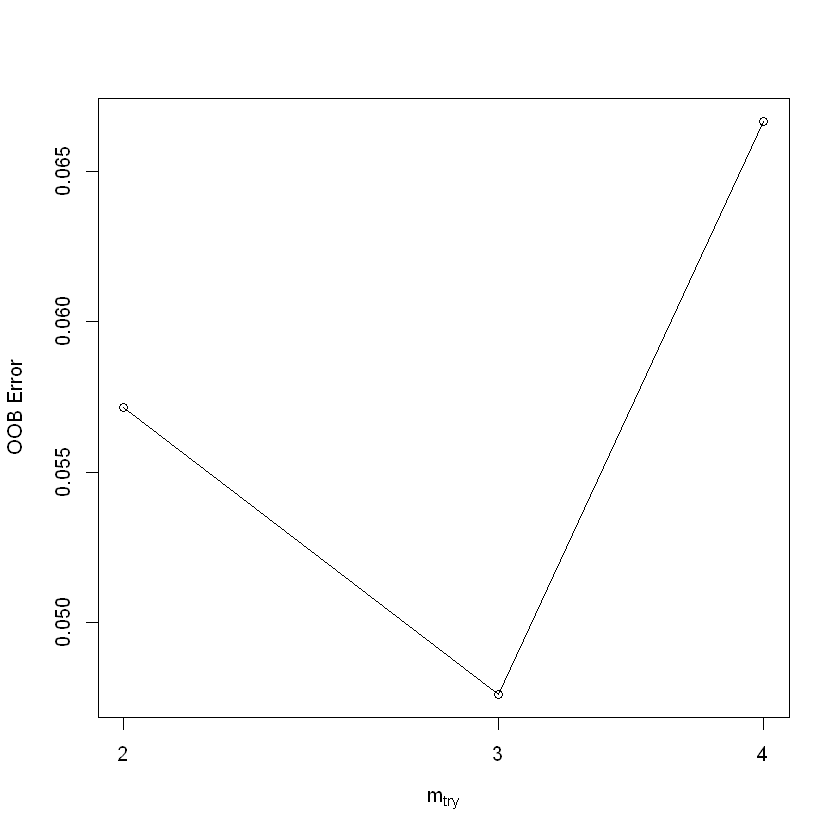

In [7]:
tune_results <- tuneRF(train_data[,-5], train_data[,5], 
                       stepFactor = 1.5, 
                       improve = 0.01, 
                       ntreeTry = 500,
                       plot = TRUE,
                       trace = TRUE)

In [8]:
predictions <- predict(rf_model, test_data)
conf_matrix <- table(Actual = test_data$Species, Predicted = predictions)

print("--- Confusion Matrix (Test Data) ---")
print(conf_matrix)

[1] "--- Confusion Matrix (Test Data) ---"
            Predicted
Actual       setosa versicolor virginica
  setosa         12          0         0
  versicolor      0         14         1
  virginica       0          1        17


In [9]:

accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)
print(paste("Final Accuracy:", round(accuracy * 100, 2), "%"))

[1] "Final Accuracy: 95.56 %"
